<a href="https://colab.research.google.com/github/julmiha25-sys/Python/blob/main/%D0%98%D0%BD%D1%84%D0%BE%D1%80%D0%BC%D0%B0%D1%86%D0%B8%D0%BE%D0%BD%D0%BD%D0%B0%D1%8F_%D0%B1%D0%B5%D0%B7%D0%BE%D0%BF%D0%B0%D1%81%D0%BD%D0%BE%D1%81%D1%82%D1%8C/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D1%82%D0%B8%D0%BA%D0%B0_%D0%B0%D0%BD%D1%82%D0%B8%D0%B2%D0%B8%D1%80%D1%83%D1%81%D0%BD%D0%BE%D0%B9_%D0%B7%D0%B0%D1%89%D0%B8%D1%82%D1%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

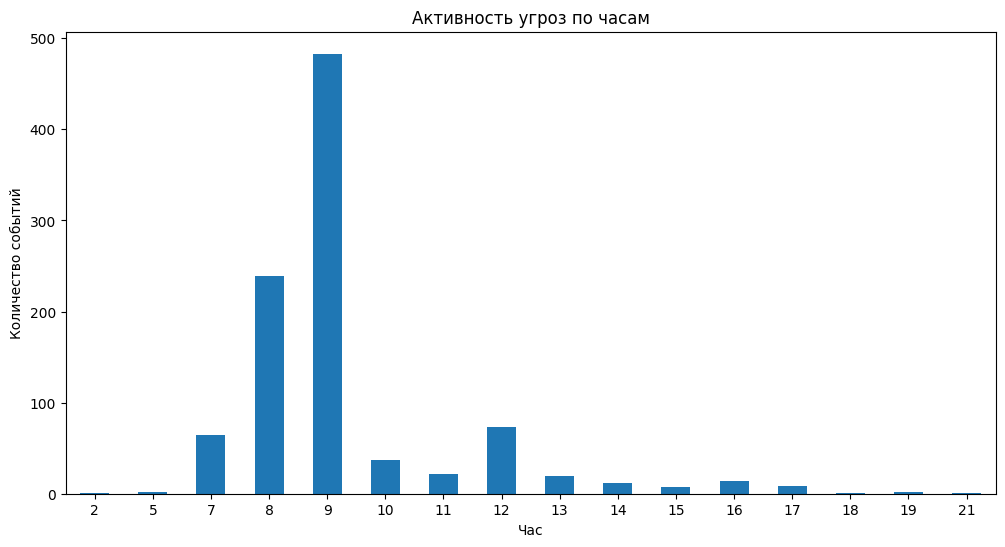

Пиковые часы атак: [9, 8, 12]
Наиболее часто блокируемые домены:
domain
avp.exe           164
dse-1901g.xml      96
config.xml         96
mr24-1901g.xml     84
sgm.mft            47
24.xms             41
manager.cpp        38
win.msi            14
mr23-1901g.xml     12
pdmkl.dat           6
Name: count, dtype: int64

Обнаружено аномальных событий: 99

Событие
Участие в KSN выключено                                                                                 25
Серверы KSN недоступны                                                                                  13
Статус устройства "Предупреждение".                                                                     10
Задача выполняется                                                                                       8
Статус устройства "Критический".                                                                         6
Установлены не все компоненты приложения, которые позволяет использовать лицензия                      

In [56]:
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import re
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder

# Поиск доменов
def extract_domain(text):
    if pd.isna(text):
        return None
    domains = re.findall(r'(?:[a-z0-9](?:[a-z0-9-]{0,61}[a-z0-9])?\.)+[a-z]{2,}', str(text))
    return domains[0] if domains else None

# Загрузка отчета с KSC
file_path = 'Отчет для python (31.03.2026 15-26-31).xls'
tree = ET.parse(file_path)
root = tree.getroot()
namespaces = {'ss': 'urn:schemas-microsoft-com:office:spreadsheet'}
worksheet = root.find(".//ss:Worksheet[@ss:Name='Details']", namespaces)
table = worksheet.find(".//ss:Table", namespaces)
data = []
for row in table.findall(".//ss:Row", namespaces):
    row_data = []
    for cell in row.findall(".//ss:Cell", namespaces):
        data_elem = cell.find(".//ss:Data", namespaces)
        if data_elem is not None:
            row_data.append(data_elem.text)
        else:
            row_data.append(None)
    data.append(row_data)
df = pd.DataFrame(data)
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df['Обнаружено'] = pd.to_datetime(df['Обнаружено'])

# Определение частоты событий по часам
df['hour'] = df['Обнаружено'].dt.hour
hourly_attacks = df.groupby('hour').size()

# Визуализация
plt.figure(figsize=(12, 6))
hourly_attacks.plot(kind='bar')
plt.title('Активность угроз по часам')
plt.xlabel('Час')
plt.ylabel('Количество событий')
plt.xticks(rotation=0)
plt.show()

# Определение пиковых часов атак
peak_hours = hourly_attacks.nlargest(3)
print(f"Пиковые часы атак: {peak_hours.index.tolist()}")

# Топ проблемных доменов
df['domain'] = df['Описание'].apply(extract_domain)
top_domains = df[df['domain'].notna()]['domain'].value_counts().head(10)
print("Наиболее часто блокируемые домены:")
print(top_domains)

# Подготовка признаков
df_features = df.copy()
df_features['hour'] = df_features['Обнаружено'].dt.hour
df_features['day_of_week'] = df_features['Обнаружено'].dt.dayofweek

# Кодирование категориальных признаков
le_event = LabelEncoder()
le_device = LabelEncoder()
le_group = LabelEncoder()
df_features['event_code'] = le_event.fit_transform(df_features['Событие'].astype(str))
df_features['device_code'] = le_device.fit_transform(df_features['Устройство'].astype(str))
df_features['group_code'] = le_group.fit_transform(df_features['Группа'].astype(str))

# Признаки для ML
ml_features = ['hour', 'day_of_week', 'event_code', 'device_code', 'group_code']

# Обнаружение аномалий
iso_forest = IsolationForest(contamination=0.1, random_state=42)
df_features['anomaly'] = iso_forest.fit_predict(df_features[ml_features])
anomalies = df_features[df_features['anomaly'] == -1]
print(f"\nОбнаружено аномальных событий: {len(anomalies)}\n")
print(anomalies['Событие'].value_counts())

# Ошибки проверки зашифрованного соединения
ssl_errors = df[df['Событие'].str.contains('ошибка проверки зашифрованного', na=False)]
print("\nОшибки SSL/сертификатов:")
print(ssl_errors['domain'].value_counts().head(10))

# Поиск устройства с SSL-ошибками
print("\nНа каких устройствах чаще всего ошибки SSL:")
print(ssl_errors['Устройство'].value_counts().head(10))

# Успешно заблокированные угрозы
blocked = df[df['Событие'].str.contains('Остановлен переход', na=False)]
print(f"\nЗаблокировано угроз: {len(blocked)}")